# IMPORT LIBRARIES

In [9]:
## To import necessary libraries
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
from common import *

# LOAD SAMPLE DATA

In [10]:
## To load the sampled data from CSV files
group_corners = pd.read_csv("../data/sample data/sample_group_corners.csv")["corners"]
knockout_corners = pd.read_csv("../data/sample data/sample_knockout_corners.csv")["corners"]

print("Group sample n:", len(group_corners))
print("Knockout sample n:", len(knockout_corners))

Group sample n: 50
Knockout sample n: 50


# CHECK DATA NORMALITY

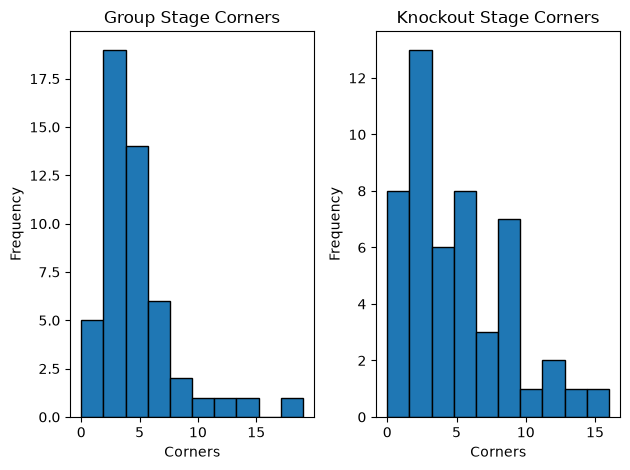

In [11]:
## To visualize normality of the data using histograms
plt.subplot(1, 2, 1)
plt.hist(group_corners, bins=10, edgecolor='black')
plt.title("Group Stage Corners")
plt.xlabel("Corners")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(knockout_corners, bins=10, edgecolor='black')
plt.title("Knockout Stage Corners")
plt.xlabel("Corners")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# BASIC STATISTICS

In [12]:
## the basic statistics of sample 1 (Group Stage)
x_bar1 = group_corners.mean()
s1 = group_corners.std(ddof=1)
n1 = len(group_corners)

## the basic statistics of sample 2 (Knockout Stage)
x_bar2 = knockout_corners.mean()
s2 = knockout_corners.std(ddof=1)
n2 = len(knockout_corners)

print("Group Stage:    Mean: %.2f. Standard deviation: %.2f. Size: %d." % (x_bar1, s1, n1))
print("Knockout Stage: Mean: %.2f. Standard deviation: %.2f. Size: %d." % (x_bar2, s2, n2))

Group Stage:    Mean: 4.56. Standard deviation: 3.52. Size: 50.
Knockout Stage: Mean: 5.00. Standard deviation: 3.68. Size: 50.


# TWO SAMPLE T-TEST

In [13]:
'''
H₀: μ= 0 (NULL HYPOTHESIS: mean of Group Stage = mean of Knockout Stage)
H1: μ≠ 0 (ALTERNATIVE HYPOTHESIS: mean of Group Stage ≠ mean of Knockout Stage)
the argument equal_var=False, which assumes that two populations do not have equal variance
'''
t_stats, p_val = st.ttest_ind_from_stats(x_bar1, s1, n1, x_bar2, s2, n2, equal_var=False, alternative='two-sided')

print("\n Computing t* ...")
print("\t t-statistic (t*): %.2f" % t_stats)

print("\n Computing p-value ...")
print("\t p-value: %.4f" % p_val)

print("\n Conclusion:")
if p_val < 0.05:
    print("\t We reject the null hypothesis.")
else:
    print("\t We accept the null hypothesis.")


 Computing t* ...
	 t-statistic (t*): -0.61

 Computing p-value ...
	 p-value: 0.5429

 Conclusion:
	 We accept the null hypothesis.


# LOG OUTPUT SUMMARY INTO TEXT FILE

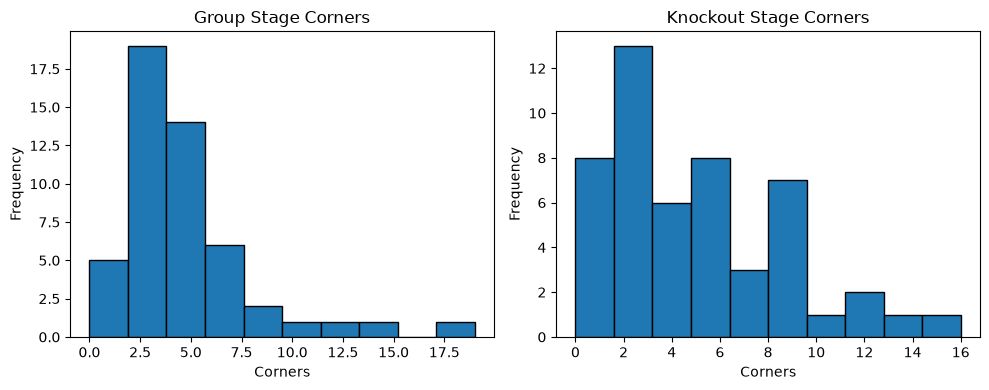



HYPOTHESIS TESTING — TWO SAMPLE T-TEST

H₀: mean of Group Stage = mean of Knockout Stage
H1: mean of Group Stage does not equal mean of Knockout Stage
(equal_var=False; unequal variances assumed)

Group Stage:    Mean: 4.56. Standard deviation: 3.52. Size: 50.
Knockout Stage: Mean: 5.00. Standard deviation: 3.68. Size: 50.

t-statistic (t*): -0.61
p-value: 0.5429

Conclusion:
We accept the null hypothesis.

Histogram saved to:
../output/05_2_two_sample_t_test_histogram.png


Output automatically saved to:
../output/05_1_two_sample_t_test_output.txt


In [19]:
# To save the histogram plot and the output of the two-sample t-test to files

hist_path = OUTPUT_FOLDER / "05_2_two_sample_t_test_histogram.png"
plot_histograms(group_corners, knockout_corners, save_path=hist_path)

output_file = OUTPUT_FOLDER / "05_1_two_sample_t_test_output.txt"

output = f"""

HYPOTHESIS TESTING — TWO SAMPLE T-TEST

H₀: mean of Group Stage = mean of Knockout Stage
H1: mean of Group Stage does not equal mean of Knockout Stage
(equal_var=False; unequal variances assumed)

Group Stage:    Mean: {x_bar1:.2f}. Standard deviation: {s1:.2f}. Size: {n1}.
Knockout Stage: Mean: {x_bar2:.2f}. Standard deviation: {s2:.2f}. Size: {n2}.

t-statistic (t*): {t_stats:.2f}
p-value: {p_val:.4f}

Conclusion:
{"We reject the null hypothesis." if p_val < 0.05 else "We accept the null hypothesis."}

Histogram saved to:
{hist_path}
"""

output_file.write_text(output, encoding="utf-8")
print(output)
print("\nOutput automatically saved to:")
print(output_file)